# 03 — Signal quality (Stage 4): common-mode rejection at the lead

Each lead is a weight vector w over electrodes. The residual common-mode conversion at the lead is

  **c = |Σᵢ wᵢ · (1 + εₙ₍ᵢ₎) · e^(−jωτₙ₍ᵢ₎) · hᵢ| + 1/CMRR_amp**,  where  **hᵢ = Z_cm,i / (Z_src,i + Z_cm,i)**

* **Z_src** is the electrode impedance in parallel with the analog line's capacitance to the skin.
* **Z_cm** is the AFE's CM input impedance in parallel with the analog line's capacitance to the ground yarn.
* **εₙ, τₙ** are the gain error and sample-time offset of sensor node n. They are shared within a node, so they cancel there.
* **System rejection** is DRL suppression (40 dB) − 20·log₁₀(c).
* **Targets:** 89 dB for 12-lead and BSPM (the IEC 60601-2-25 CMR-test equivalent), and 60 dB for R-R.

**Cases:**
* **compliance:** IEC 51 kΩ ∥ 47 nF imbalance on one electrode.
* **realistic:** dry/textile electrodes, Monte Carlo, reporting the 5th percentile (95% of garments pass).

**Sync levels:** none (skew up to one sample), timestamp + interpolation (5 µs), hardware strobe (0.5 µs).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import geometry as geo, power as pw, sigq as sq, params
pd.set_option('display.width', 200)
p = pw.P()
g = geo.Garment(C=p['torso_circ'], H=p['torso_height'], Cs=p['sleeve_circ'], Ls=p['sleeve_len'])
sites = geo.build_layout(g, 'ML', int(p['spares_per_site']))
D = geo.dist_matrix(g, sites); hub = geo.central_hub(g, sites); N = len(sites)
HUES = ['#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4','#008300','#4a3aa7','#e34948']
INK, MUTED = '#1f1f1e', '#6b6a64'
PT = {m: geo.build_point(g, sites, D, m, 4, 'mesh', 'mesh', hub) for m in [1, 2, 3, 4, 8, 16, N]}
def lab(m): return 'N' if m == N else str(m)
def style(ax, title, xl, yl):
    ax.set_title(title, loc='left', fontsize=11, color=INK); ax.set_xlabel(xl, color=MUTED); ax.set_ylabel(yl, color=MUTED)
    ax.grid(color='#ecebe6'); ax.set_axisbelow(True)
    for s_ in ('top', 'right'): ax.spines[s_].set_visible(False)

## Validation (V-02)

1. **Textbook check.** For two electrodes with ideal gains, the model should reduce to the classical potential-divider result c ≈ |ΔZ_e| / |Z_cm| (Winter & Webster 1983).
2. **Dabbaghian '24.** The paper reports 82.2 dB with two active electrodes and no mismatch, and < 5 dB degradation at 1 MΩ of electrode mismatch, with Z_in = 5.5 GΩ at 60 Hz.

In [2]:
# 1. textbook
ZA, ZB = 100e3, 1.1e6
Zcm = 1 / (1j * sq.W60 * 10e-12)
h = lambda z: Zcm / (z + Zcm)
model = abs(h(ZA) - h(ZB)); textbook = abs(ZB - ZA) / abs(Zcm)
print(f"textbook check: model {20*np.log10(model):.2f} dB vs |dZ|/|Zcm| {20*np.log10(textbook):.2f} dB")

# 2. Dabbaghian: Zin 5.5 GOhm at 60 Hz (treated as capacitive), resistive 1 MOhm mismatch, intrinsic 82.2 dB
Zin = 1 / (1j * sq.W60 * (1 / (sq.W60 * 5.5e9)))
intrinsic = 10 ** (-82.2 / 20)
conv_mis = abs(Zin / (0 + Zin) - Zin / (1e6 + Zin))
add_lin = 20*np.log10(intrinsic + conv_mis); add_quad = 20*np.log10(np.hypot(intrinsic, conv_mis))
print(f"Dabbaghian: predicted rejection with 1 MOhm mismatch {-add_quad:.1f} dB (quadrature) to {-add_lin:.1f} dB (worst-case add)")
print(f"  -> predicted degradation {82.2 + add_quad:.1f} to {82.2 + add_lin:.1f} dB vs reported < 5 dB")

textbook check: model -48.47 dB vs |dZ|/|Zcm| -48.47 dB
Dabbaghian: predicted rejection with 1 MOhm mismatch 74.1 dB (quadrature) to 71.7 dB (worst-case add)
  -> predicted degradation 8.1 to 10.5 dB vs reported < 5 dB


## Baseline: pass/fail by architecture, sync level and case (gain mismatch 1%, n = 4, mesh)

In [3]:
rows = []
for m, pt in PT.items():
    for case in ['compliance', 'realistic']:
        for sync in ['none', 'ts', 'hw']:
            r = dict(m=lab(m), case=case, sync=sync)
            for mode in ['RR', '12L', 'BSPM']:
                _, rej = sq.lead_rejection(sites, D, pt, mode, p, case, sync)
                v, ok = sq.mode_metric(rej, mode, p)
                r[mode] = (f"{v:.0f} dB" if mode != 'BSPM' else f"{v*100:.0f}% leads") + (' ✓' if ok else ' ✗')
            rows.append(r)
B = pd.DataFrame(rows)
B.pivot_table(index=['m'], columns=['case', 'sync'], values='12L', aggfunc='first').reindex([lab(m) for m in PT])

case compliance                     realistic                  
sync         hw      none        ts        hw     none       ts
m                                                              
1       81 dB ✗   44 dB ✗   81 dB ✗   80 dB ✗  44 dB ✗  80 dB ✗
2       81 dB ✗   44 dB ✗   81 dB ✗   80 dB ✗  44 dB ✗  80 dB ✗
3       81 dB ✗   44 dB ✗   81 dB ✗   80 dB ✗  44 dB ✗  80 dB ✗
4       81 dB ✗   44 dB ✗   81 dB ✗   80 dB ✗  44 dB ✗  80 dB ✗
8       81 dB ✗   44 dB ✗   81 dB ✗   80 dB ✗  44 dB ✗  80 dB ✗
16      81 dB ✗   44 dB ✗   81 dB ✗   79 dB ✗  44 dB ✗  79 dB ✗
N      114 dB ✓  114 dB ✓  114 dB ✓   80 dB ✗  80 dB ✗  80 dB ✗

In [4]:
B[B.sync == 'hw'].pivot_table(index='m', columns='case', values=['RR', 'BSPM'], aggfunc='first').reindex([lab(m) for m in PT])

BSPM                      RR          
case    compliance    realistic compliance realistic
m                                                   
1      55% leads ✗  50% leads ✗    86 dB ✓   86 dB ✓
2      48% leads ✗  43% leads ✗   119 dB ✓   92 dB ✓
3      50% leads ✗  47% leads ✗   120 dB ✓   92 dB ✓
4      48% leads ✗  43% leads ✗   119 dB ✓   92 dB ✓
8      43% leads ✗  42% leads ✗   118 dB ✓   89 dB ✓
16     45% leads ✗  32% leads ✗   118 dB ✓   88 dB ✓
N     100% leads ✓  33% leads ✗   114 dB ✓   83 dB ✓

## What distributed 12-lead needs: gain matching (realistic electrodes, AFE input C = 2 pF)

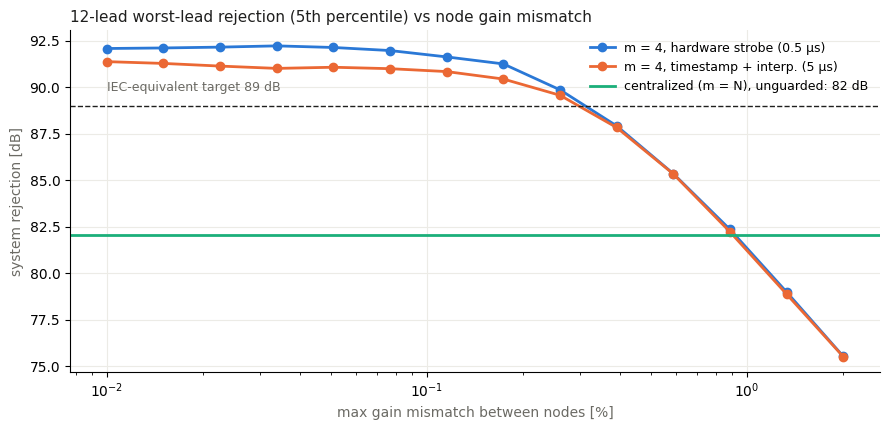

In [5]:
gm = np.logspace(-2, np.log10(2), 14)
fig, ax = plt.subplots(figsize=(9, 4.4))
for ci, (sync, lbl) in enumerate([('hw', 'hardware strobe (0.5 µs)'), ('ts', 'timestamp + interp. (5 µs)')]):
    ys = []
    for gg in gm:
        _, rej = sq.lead_rejection(sites, D, PT[4], '12L', dict(p, gain_mismatch=gg, Zin_C=2), 'realistic', sync)
        ys.append(sq.mode_metric(rej, '12L', p)[0])
    ax.plot(gm, ys, color=HUES[ci], lw=2, marker='o', ms=6, label=f'm = 4, {lbl}')
_, rejc = sq.lead_rejection(sites, D, PT[N], '12L', dict(p, Zin_C=2), 'realistic', 'hw')
vc = sq.mode_metric(rejc, '12L', p)[0]
ax.axhline(vc, color=HUES[2], lw=2, ls='-', label=f'centralized (m = N), unguarded: {vc:.0f} dB')
ax.axhline(p['rej_target_diag'], color=INK, lw=1, ls='--'); ax.text(gm[0], p['rej_target_diag'] + 0.8, 'IEC-equivalent target 89 dB', fontsize=9, color=MUTED)
ax.set_xscale('log'); ax.legend(frameon=False, fontsize=9)
style(ax, '12-lead worst-lead rejection (5th percentile) vs node gain mismatch', 'max gain mismatch between nodes [%]', 'system rejection [dB]')
plt.tight_layout(); plt.savefig('sq_gain_requirement.png', dpi=160); plt.show()

## Spec map for the distributed sensor chiplet: gain matching × sample alignment (m = 4, realistic, AFE input C = 2 pF)

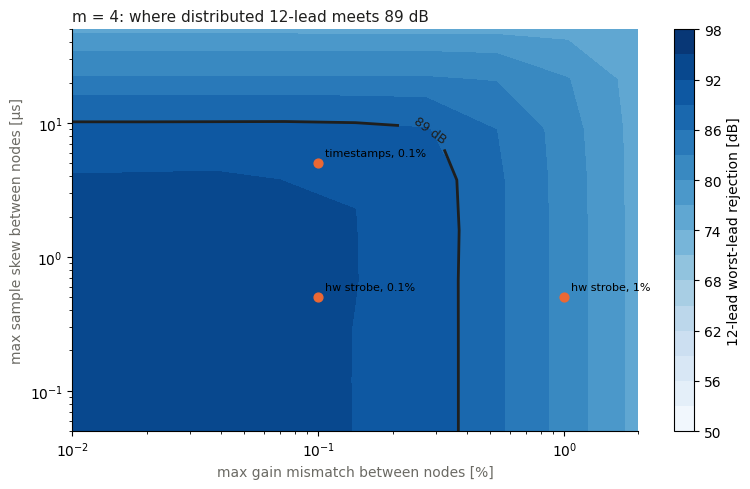

In [6]:
gms = np.logspace(-2, np.log10(2), 9); sks = np.logspace(np.log10(0.05), np.log10(50), 9)
Z = np.zeros((len(sks), len(gms)))
for i, sk in enumerate(sks):
    for j, gg in enumerate(gms):
        _, rej = sq.lead_rejection(sites, D, PT[4], '12L', dict(p, gain_mismatch=gg, skew_hw=sk, Zin_C=2), 'realistic', 'hw', trials=200)
        Z[i, j] = sq.mode_metric(rej, '12L', p)[0]
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.contourf(gms, sks, Z, levels=np.arange(50, 100, 3), cmap='Blues')
cs = ax.contour(gms, sks, Z, levels=[p['rej_target_diag']], colors=INK, linewidths=2)
ax.clabel(cs, fmt={p['rej_target_diag']: '89 dB'}, fontsize=9)
ax.set_xscale('log'); ax.set_yscale('log')
cb = plt.colorbar(im, ax=ax); cb.set_label('12-lead worst-lead rejection [dB]')
for x, y, t in [(1, 0.5, 'hw strobe, 1%'), (0.1, 0.5, 'hw strobe, 0.1%'), (0.1, 5, 'timestamps, 0.1%')]:
    ax.scatter(x, y, color=HUES[1], s=40, zorder=5); ax.annotate(t, (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8)
style(ax, 'm = 4: where distributed 12-lead meets 89 dB', 'max gain mismatch between nodes [%]', 'max sample skew between nodes [µs]')
ax.grid(False)
plt.tight_layout(); plt.savefig('sq_spec_map_gain_skew.png', dpi=160); plt.show()

## Required AFE input capacitance (realistic electrodes; distributed at 0.1% gain, hardware strobe)

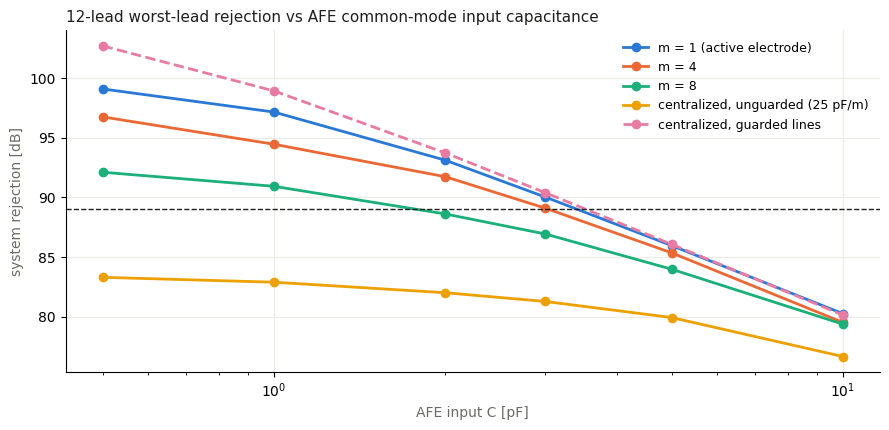

,m = 1 (active electrode),m = 4,m = 8,"centralized, unguarded (25 pF/m)","centralized, guarded lines"
0.5 pF,99.1,96.7,92.1,83.3,102.7
1 pF,97.2,94.5,90.9,82.9,98.9
2 pF,93.1,91.7,88.6,82.0,93.7
3 pF,90.0,89.1,86.9,81.3,90.4
5 pF,86.0,85.4,84.0,79.9,86.1
10 pF,80.3,79.5,79.4,76.7,80.1


In [7]:
cins = [0.5, 1, 2, 3, 5, 10]
fig, ax = plt.subplots(figsize=(9, 4.4))
cfgs = [(1, {}, 'm = 1 (active electrode)'), (4, {}, 'm = 4'), (8, {}, 'm = 8'),
        (N, {}, 'centralized, unguarded (25 pF/m)'), (N, {'C_line_gnd': 0}, 'centralized, guarded lines')]
CIN = {}
for ci, (m, extra, lbl) in enumerate(cfgs):
    ys = []
    for cin in cins:
        _, rej = sq.lead_rejection(sites, D, PT[m], '12L', dict(p, Zin_C=cin, gain_mismatch=0.1, **extra), 'realistic', 'hw')
        ys.append(sq.mode_metric(rej, '12L', p)[0])
    CIN[lbl] = ys
    ax.plot(cins, ys, color=HUES[ci], lw=2, marker='o', ms=6, label=lbl, ls='--' if 'guarded lines' in lbl else '-')
ax.axhline(p['rej_target_diag'], color=INK, lw=1, ls='--')
ax.set_xscale('log'); ax.legend(frameon=False, fontsize=9)
style(ax, '12-lead worst-lead rejection vs AFE common-mode input capacitance', 'AFE input C [pF]', 'system rejection [dB]')
plt.tight_layout(); plt.savefig('sq_input_cap_requirement.png', dpi=160); plt.show()
pd.DataFrame(CIN, index=[f'{c} pF' for c in cins]).round(1)

## Sensitivity to DRL suppression (AFE input C = 5 pF; distributed at 0.1% gain)

In [8]:
rows = []
for d in [30, 40, 50, 60]:
    r = {'DRL [dB]': d}
    for m, lbl, extra in [(4, 'm=4', {'gain_mismatch': 0.1}), (N, 'centralized unguarded', {}), (N, 'centralized guarded', {'C_line_gnd': 0})]:
        _, rej = sq.lead_rejection(sites, D, PT[m], '12L', dict(p, cm_suppression_drl=d, **extra), 'realistic', 'hw')
        r[lbl] = round(sq.mode_metric(rej, '12L', p)[0], 1)
    rows.append(r)
pd.DataFrame(rows)

,DRL [dB],m=4,centralized unguarded,centralized guarded
0,30,75.4,69.9,76.1
1,40,85.4,79.9,86.1
2,50,95.4,89.9,96.1
3,60,105.4,99.9,106.1


## What centralized 12-lead needs: line-to-ground capacitance (guarding) and AFE input capacitance

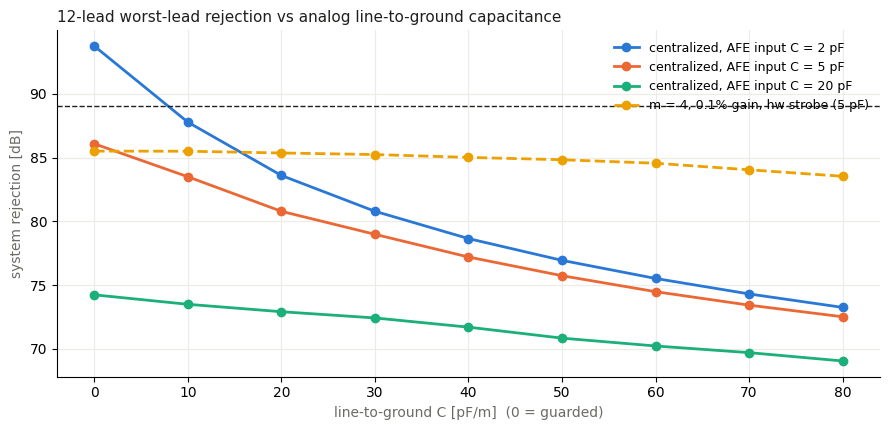

In [9]:
clg = np.linspace(0, 80, 9)
fig, ax = plt.subplots(figsize=(9, 4.4))
for ci, cin in enumerate([2, 5, 20]):
    ys = []
    for c in clg:
        _, rej = sq.lead_rejection(sites, D, PT[N], '12L', dict(p, C_line_gnd=c, Zin_C=cin), 'realistic', 'hw')
        ys.append(sq.mode_metric(rej, '12L', p)[0])
    ax.plot(clg, ys, color=HUES[ci], lw=2, marker='o', ms=6, label=f'centralized, AFE input C = {cin} pF')
ys4 = []
for c in clg:
    _, rej = sq.lead_rejection(sites, D, PT[4], '12L', dict(p, C_line_gnd=c, gain_mismatch=0.1), 'realistic', 'hw')
    ys4.append(sq.mode_metric(rej, '12L', p)[0])
ax.plot(clg, ys4, color=HUES[3], lw=2, ls='--', marker='o', ms=6, label='m = 4, 0.1% gain, hw strobe (5 pF)')
ax.axhline(p['rej_target_diag'], color=INK, lw=1, ls='--')
ax.legend(frameon=False, fontsize=9)
style(ax, '12-lead worst-lead rejection vs analog line-to-ground capacitance', 'line-to-ground C [pF/m]  (0 = guarded)', 'system rejection [dB]')
plt.tight_layout(); plt.savefig('sq_centralized_guarding.png', dpi=160); plt.show()

## Sensitivity to the electrode assumption (median dry-electrode R, realistic case)

In [10]:
rows = []
for R in [0.5, 1, 2, 4, 8]:
    pr = dict(p, Ze_R_med=R)
    r = {'Ze_R_med [MOhm]': R}
    for m, lbl, extra in [(N, 'centralized', {}), (4, 'm=4, 1% gain', {}), (4, 'm=4, 0.1% gain', {'gain_mismatch': 0.1})]:
        _, rej = sq.lead_rejection(sites, D, PT[m], '12L', dict(pr, **extra), 'realistic', 'hw')
        r[lbl] = round(sq.mode_metric(rej, '12L', p)[0], 1)
    rows.append(r)
pd.DataFrame(rows)

,Ze_R_med [MOhm],centralized,"m=4, 1% gain","m=4, 0.1% gain"
0,0.5,85.8,81.3,91.4
1,1.0,82.4,81.0,88.2
2,2.0,79.9,80.3,85.4
3,4.0,77.8,79.8,82.9
4,8.0,76.0,78.7,81.3


## Noise check (first order): lead IRN vs the 30 µV p-v limit

In [11]:
for mode, (names, W) in {'12L': sq.twelve_lead_weights(sites), 'BSPM': sq.bspm_weights(sites)}.items():
    nz = sq.lead_noise_uvpp(W, p, mode)
    print(f"{mode}: worst lead {nz.max():.1f} uVp-p (limit 30), median {np.median(nz):.1f}")

12L: worst lead 9.3 uVp-p (limit 30), median 7.9
BSPM: worst lead 7.6 uVp-p (limit 30), median 7.6


## Power and signal quality together (n = 4 mesh, spec case at a 10 µW orchestrator floor; centralized unguarded)

In [12]:
rows = []
for m, pt in PT.items():
    P = pw.average_power(sites, D, pt, p, 'spec', 10e-6)['total'] * 1e6
    for scen, extra, sync in [('baseline: 5 pF, 1% gain, timestamps', {}, 'ts'), ('spec AFE: 2 pF, 0.1% gain, timestamps', {'gain_mismatch': 0.1, 'Zin_C': 2}, 'ts')]:
        _, rej = sq.lead_rejection(sites, D, pt, '12L', dict(p, **extra), 'realistic', sync)
        v, ok = sq.mode_metric(rej, '12L', p)
        _, rr = sq.lead_rejection(sites, D, pt, 'RR', dict(p, **extra), 'realistic', sync)
        vr, okr = sq.mode_metric(rr, 'RR', p)
        _, rb = sq.lead_rejection(sites, D, pt, 'BSPM', dict(p, **extra), 'realistic', sync)
        vb, okb = sq.mode_metric(rb, 'BSPM', p)
        rows.append(dict(m=lab(m), scenario=scen, power_uW=round(P), rej_12L=round(v, 1), ok_12L=ok, rej_RR=round(vr, 1), ok_RR=okr,
                         bspm_frac=round(vb, 2), ok_BSPM=okb, analog_max_cm=round(pt.analog_max_cm)))
F = pd.DataFrame(rows)
F.to_csv('power_sq_feasibility.csv', index=False)
F

,m,scenario,power_uW,rej_12L,ok_12L,rej_RR,ok_RR,bspm_frac,ok_BSPM,analog_max_cm
0,1,"baseline: 5 pF, 1% gain, timestamps",540,80.3,False,85.6,True,0.50,False,0
1,1,"spec AFE: 2 pF, 0.1% gain, timestamps",540,92.0,True,97.1,True,1.00,True,0
2,2,"baseline: 5 pF, 1% gain, timestamps",312,80.5,False,92.0,True,0.42,False,25
3,2,"spec AFE: 2 pF, 0.1% gain, timestamps",312,90.7,True,96.7,True,0.97,True,25
4,3,"baseline: 5 pF, 1% gain, timestamps",246,79.8,False,92.4,True,0.45,False,13
5,3,"spec AFE: 2 pF, 0.1% gain, timestamps",246,87.9,False,98.3,True,0.97,True,13
6,4,"baseline: 5 pF, 1% gain, timestamps",205,80.3,False,91.9,True,0.43,False,17
7,4,"spec AFE: 2 pF, 0.1% gain, timestamps",205,91.0,True,97.1,True,0.93,False,17
8,8,"baseline: 5 pF, 1% gain, timestamps",167,79.8,False,89.2,True,0.40,False,25
9,8,"spec AFE: 2 pF, 0.1% gain, timestamps",167,88.2,False,93.0,True,0.93,False,25


## Findings (ML, 1 spare per site, n = 4 mesh, realistic = dry electrodes ~1 MΩ with ~2× spread, 5th percentile)

1. **Validation.** The model reproduces the textbook divider result (|ΔZ|/|Z_cm|) exactly. For Dabbaghian '24 it predicts 8–10 dB of degradation at 1 MΩ mismatch, against < 5 dB reported, so it is conservative by about 3–5 dB. The likely reasons are the in-channel CM boost and the test conditions; this needs checking against the paper's setup.
2. **Baseline front end (5 pF input, 1% node gain mismatch): nothing meets 89 dB on dry electrodes.**
   * Distributed 12-lead is limited by gain mismatch at about 80 dB.
   * Centralized unguarded is limited by line capacitance at about 80 dB.
   * R-R passes everywhere (≥ 83 dB against a 60 dB target), because R-R leads are local and differential.
3. **Cross-node leads need sync, but only to the microsecond level.**
   * Unsynced ADCs give about 44 dB, which fails badly.
   * Timestamps with interpolation (about 5 µs) are within 1 dB of a hardware strobe, and the 89 dB contour sits near 10 µs of skew.
   * So a hardware sample strobe is not required, but timestamp sync with interpolation is a **chip-spec requirement**. THReaD doesn't have it.
4. **The distributed chiplet spec for 12-lead at 89 dB** (with 40 dB DRL): AFE input C ≲ 2.5–3 pF, node gain matching ≲ 0.35% (calibration), and skew ≲ 10 µs.
   * With 2 pF, 0.1% and timestamps, m = 1, 2 and 4 pass 12-lead.
   * m ≥ 8 fails: longer analog runs lower Z_cm.
   * m = 3 is about 1 dB below the line, which is a clustering/layout effect of about ±2 dB.
   * **m = 4 is the largest, and therefore lowest-power, distributed design that passes.**
5. **Centralized needs guarded analog lines.**
   * Unguarded (25 pF/m to the ground yarn), it never passes, reaching only about 82–83 dB even with a 0.5–2 pF AFE.
   * With guarded or driven-shield lines and ≤ 3 pF input it passes (93.7 dB at 2 pF), and it is still the lowest-power design (102 µW plus a few µW of guard buffers; revised power model).
   * **So on power and CMR alone, the comparison comes down to whether about 20 m of guarded analog textile yarn is practical.**
6. **The DRL assumption moves every result 1:1.** At 50 dB of DRL, centralized unguarded reaches about 90 dB. The pass/fail lines are therefore sensitive, but the *relative* results hold: distributed is about 5 dB better than unguarded centralized and about equal to guarded centralized.
7. **Electrode impedance matters.** Every 2× increase in median R costs about 2–3 dB, and m = 4 at 0.1% gain passes only below a median R of about 1 MΩ (with a 5 pF input).
8. **Noise is not a discriminator.** Lead noise is ≤ 9.3 µV p-p against the 30 µV limit.
